# Mantispy in ten minutes

This page runs an image-based profiling screen from the raw object to a mechanism call, on one dataset, in one
narrative. Every analytical step names a biological question, runs a few lines, draws a figure, and reads it back
off. The other tutorials each take one of these steps in depth; here the point is the whole shape of the workflow.

Everything is a scverse object. `adata.obs` records where each profile came from, `adata.var` records what each
feature measures, and `adata.uns["mantispy"]` holds every result table. scanpy's PCA, neighbours and embeddings
work on it unchanged, so no result exists only in a notebook variable.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

import mantispy as mt

## A screen in one object

BBBC021 is the field's reference compound screen: MCF-7 cells, 38 compounds at one to seven concentrations, with
published mechanism-of-action labels. `mt.ds.bbbc021()` downloads and caches it, and hands back an ordinary
`AnnData`.

In [2]:
adata = mt.ds.bbbc021()
adata

/ictstr01/groups/ml01/workspace/ttreis/projects/mantispy/.claude/worktrees/tutorial-frame/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 632 × 467
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Control', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

Rows are wells, columns are CellProfiler features, and every `Metadata_` column in `obs` says what a well is: its
plate, its compound and concentration, its mechanism label, its cell count. Nothing here is mantispy-specific yet
— a scanpy user already knows this object.

## Is the data worth analyzing?

Before any modelling, two questions decide whether the screen is usable: do treated wells look different from the
negative controls at all, and how much of what we see is the plate rather than the biology? We put every plate on
the scale of its own DMSO wells, keep the informative features, and look at a PCA.

/localscratch/tim.treis/ipykernel_571129/3300836858.py:1: UserWarning: 2 of 467 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon", keep_raw=True)


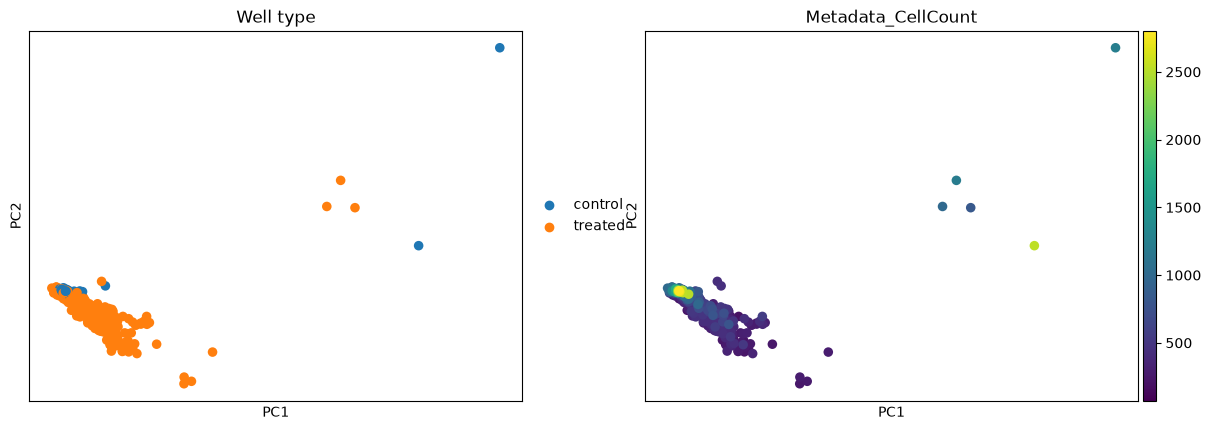

In [3]:
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon", keep_raw=True)
mt.pp.feature_select(adata, na_cutoff=0.0)
adata = mt.pp.subset_features(adata)

sc.pp.pca(adata, n_comps=30)
adata.obs["Well type"] = np.where(adata.obs["Metadata_Control"].to_numpy(), "control", "treated")
sc.pl.pca(adata, color=["Well type", "Metadata_CellCount"], ncols=2, show=False)
plt.show()

The controls sit together and the treated wells fan out around them, so there is a signal to call. Cell count
varies smoothly across the same map, a reminder that a well with few cells can move for reasons unrelated to the
compound — a confounder we return to under hits.

A screen is also only as good as its replicates. `tl.replicate_saturation` asks how much a treatment's signature
still changes as replicates are added; a curve still climbing means the next screen wants more wells.

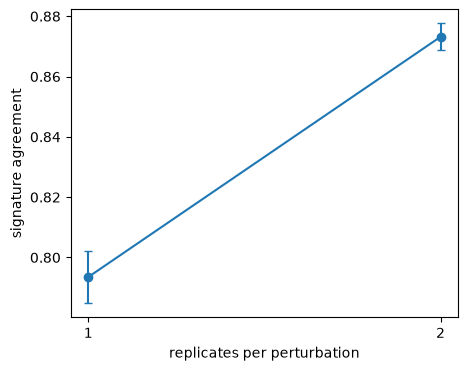

In [4]:
treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
mt.tl.replicate_saturation(treated, metric="convergence", n_draws=10)
ax = mt.pl.replicate_saturation(treated)
plt.show()

Agreement rises from one replicate to two and is still climbing at the deepest the data allows. BBBC021's two to
three replicates per treatment are on the low side for separating mechanisms — worth knowing before trusting a
marginal call.

## From cells/wells to clean profiles

BBBC021 ships at well level, so there is no cell-to-well aggregation step here (on single cells it would be
`wells = mt.tl.aggregate(cells)`). What the normalization above did is easiest to see as a before-and-after of a
few features, split into control and treated wells.

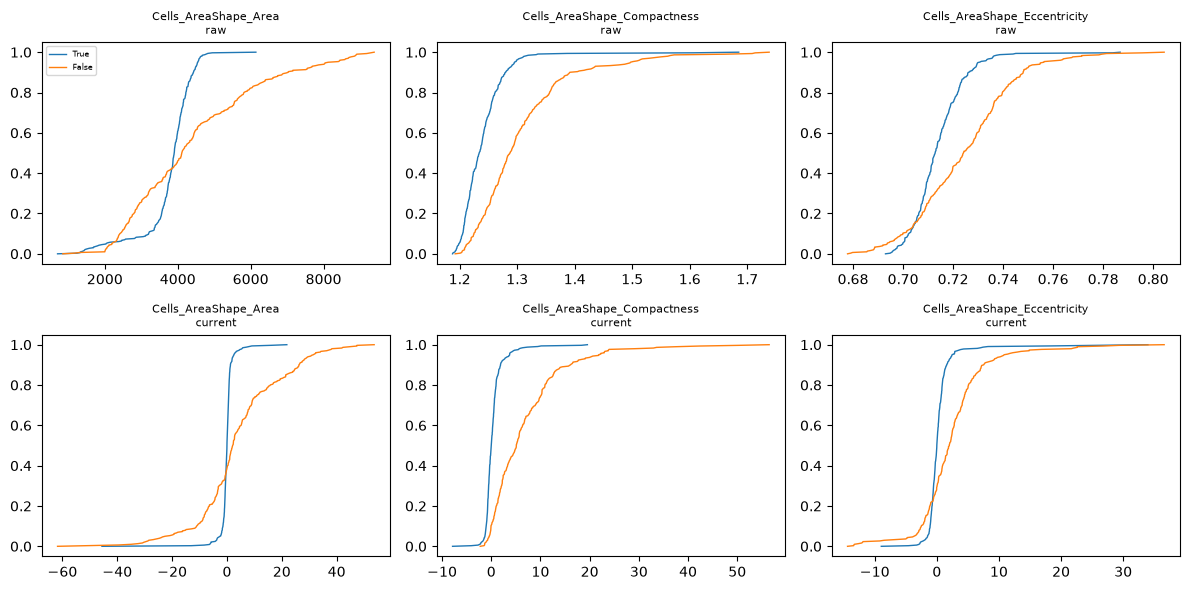

In [5]:
mt.pl.feature_distributions(adata, features=list(adata.var_names[:3]), groupby="Metadata_Control")
plt.show()

Before normalization each plate's controls sit wherever that plate's staining landed; after, the control wells are
centred on zero by construction, and a treated well is read as its distance from that shared baseline. Every
downstream distance is measured on this cleaned scale.

## One profile per treatment

Replicate wells of a treatment are noisy, and a screen is easier to reason about as one signature per treatment.
`tl.consensus` collapses replicates, taking the median by default (what pycytominer does).

In [6]:
signatures = mt.tl.consensus(treated, method="median", min_replicates=1)
signatures = signatures[signatures.obs["Metadata_MOA"].notna().to_numpy()].copy()
print(
    f"{treated.n_obs} treated wells -> {signatures.n_obs} treatment signatures"
    f" over {signatures.obs['Metadata_MOA'].nunique()} mechanisms"
)

302 treated wells -> 103 treatment signatures over 12 mechanisms


One row per treatment now, each the median of its replicate wells. These signatures are what the mechanism step
compares.

## What is a hit?

A hit is a treatment whose profile moved away from the controls by more than the controls vary among themselves.
`tl.hit_calling` scores that distance in the controls' own covariance and gives it a permutation p-value;
`tl.effect_size` then says which features moved.

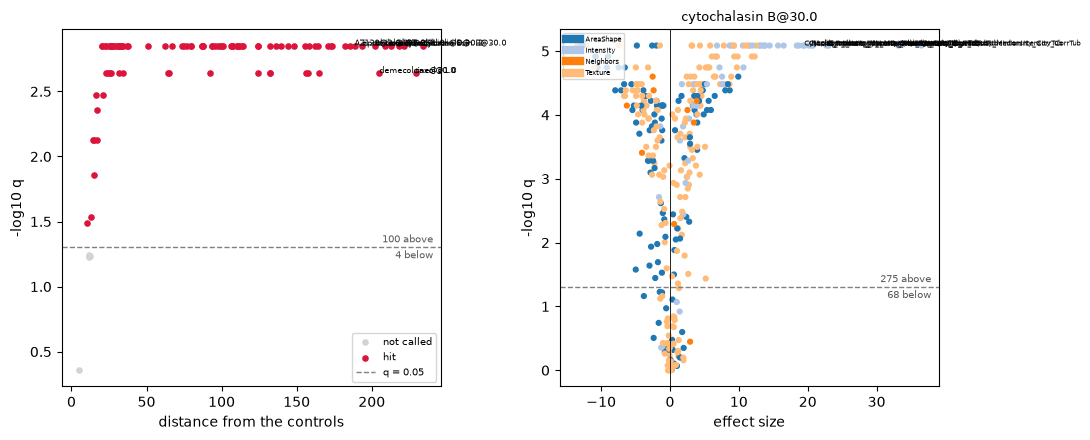

In [7]:
mt.tl.hit_calling(adata, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=1000)
mt.tl.effect_size(adata, groupby="Metadata_Perturbation")

hits = adata.uns["mantispy"]["hits"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
mt.pl.hits(adata, ax=axes[0])
mt.pl.feature_volcano(adata, group=hits.nlargest(1, "distance")["group"].iloc[0], ax=axes[1])
fig.tight_layout()
plt.show()

Most treatments clear the threshold and the DMSO control does not — the assay separates active from inactive. The
volcano for the strongest hit names the individual measurements carrying its phenotype, which is the handle for
asking what the compound does.

One caveat before trusting a strong hit: a compound that kills most of the cells also moves the well median, for
reasons that are not the biology being screened. `tl.cytotoxicity` reads distance against viability so the two can
be told apart.

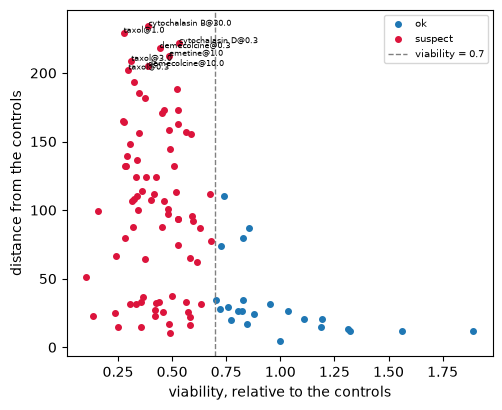

In [8]:
mt.tl.cytotoxicity(adata)
ax = mt.pl.cytotoxicity(adata)
plt.show()

Groups in the upper left are far from the controls and have lost most of their cells — suspect, not necessarily
biology. A large distance with intact viability is the hit worth following.

## What does it do?

Mechanism is a retrieval question: does a treatment's nearest neighbour share its mechanism, and where the assay
fails, which mechanisms does morphology confuse? `tl.nn_moa_classify` with the not-same-compound rule — a compound
must be recognised from a *different* molecule with the same mechanism — answers the first.

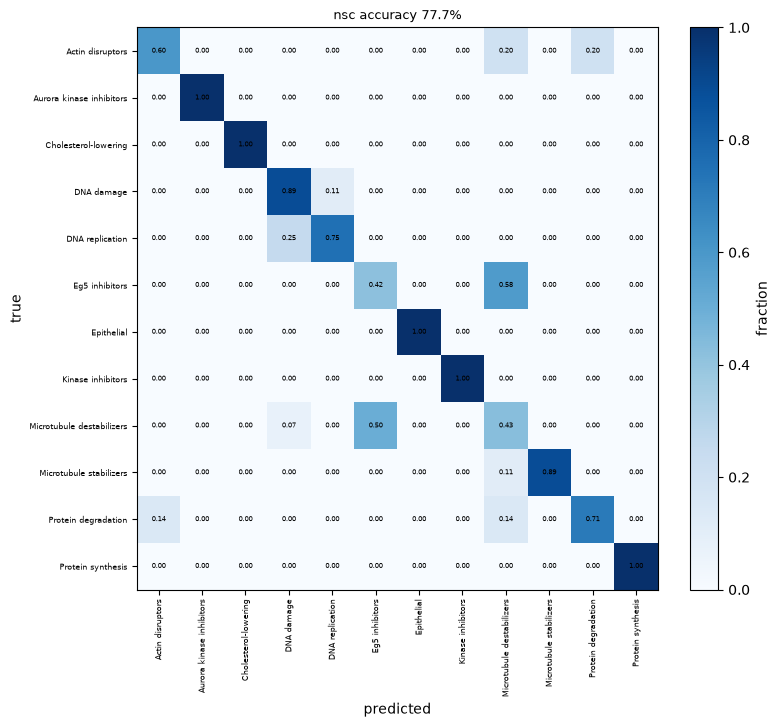

In [9]:
mt.tl.nn_moa_classify(signatures, scheme="nsc")
ax = mt.pl.moa_confusion(signatures)
plt.show()

The diagonal dominates: most treatments retrieve a different compound with the same mechanism. The largest
off-diagonal block, Eg5 inhibitors against microtubule destabilizers, is biology — both arrest mitosis and look
alike here — not a failure of the classifier.

The whole map at once: `tl.edistance` gives every treatment-by-treatment distance, and `pl.distance_heatmap`
orders it by mechanism so related treatments form blocks on the diagonal.

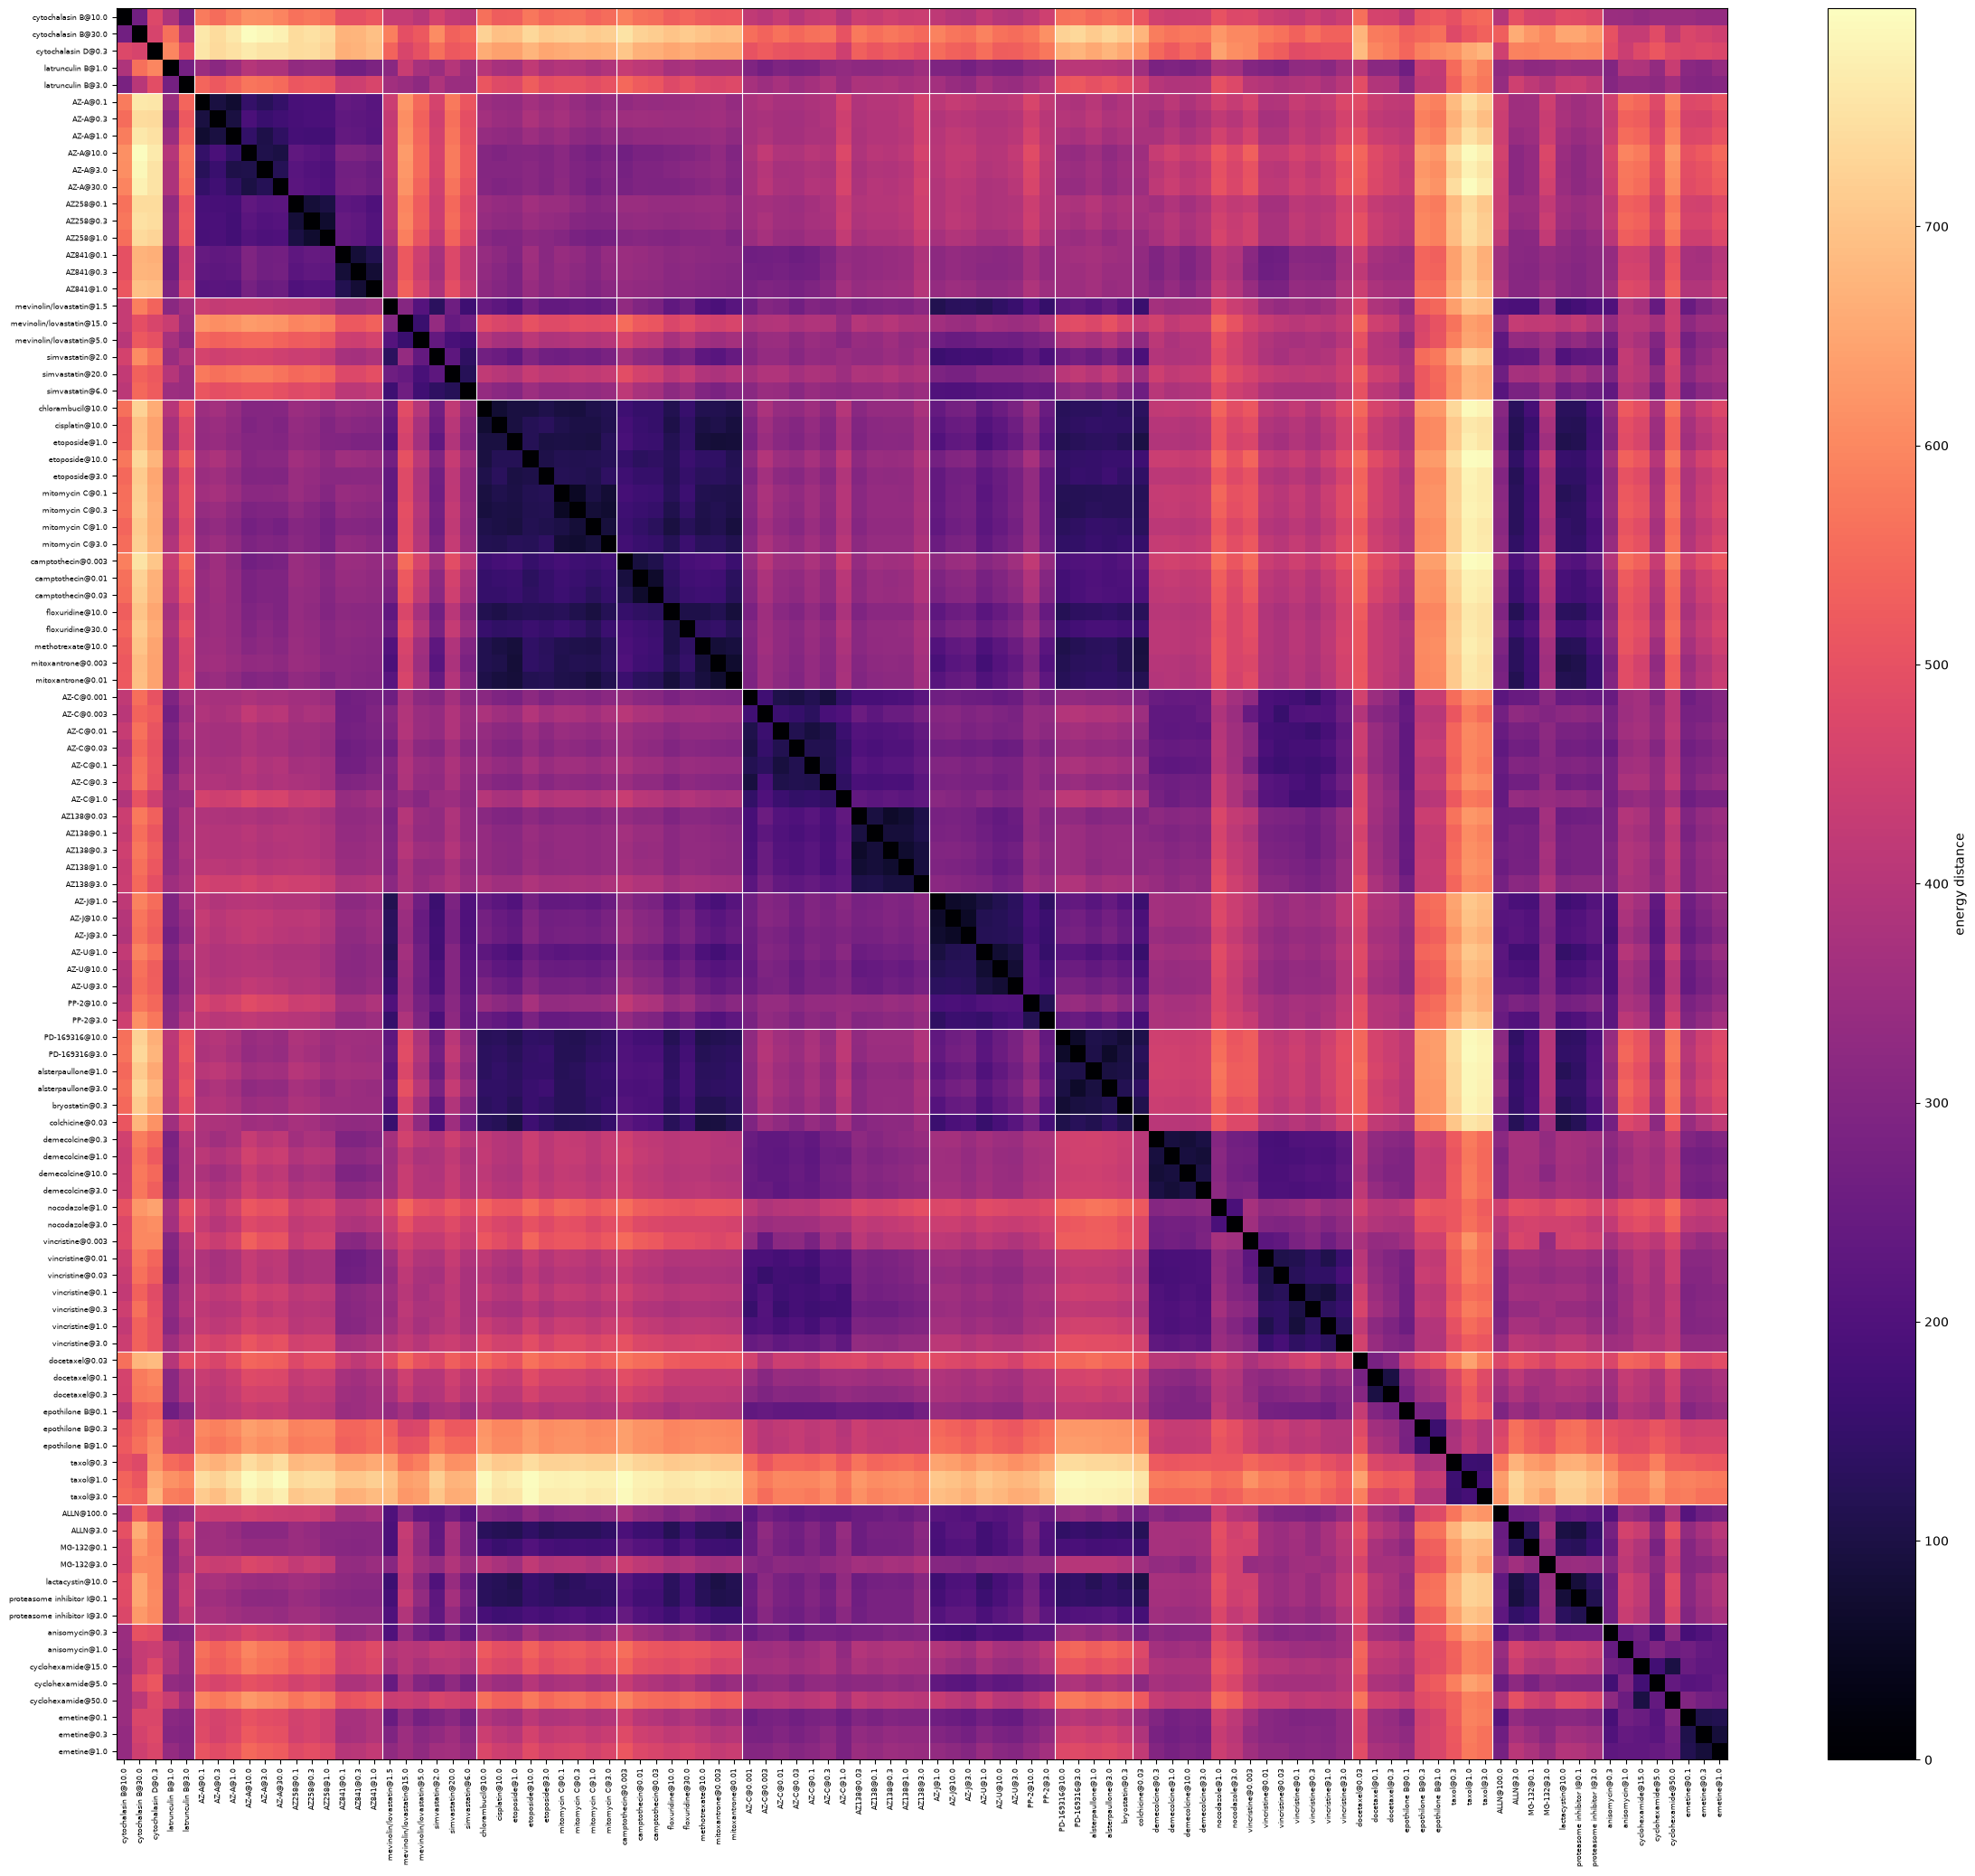

In [10]:
mt.tl.edistance(signatures, reference=None)
ax = mt.pl.distance_heatmap(signatures, groupby="Metadata_MOA")
plt.show()

Mechanism blocks stand out along the diagonal — compounds that share a mechanism sit close — while the off-diagonal
shows which mechanisms the assay cannot separate. This is the same structure the confusion matrix summarised, now
laid out treatment by treatment.

## Everything is on the object

Nothing above returned a result that lives only in a notebook variable. Hits and effect sizes are on `adata`, the
mechanism call is on `signatures`, and each result is a table under `uns["mantispy"]`, beside the provenance of the
step that wrote it.

`mt.io.write` saves the object and every one of these tables in one `.h5ad`, and `mt.io.read` brings them back —
the same file a scanpy user can open.

## Where to go next

Each modality has its own tutorial that goes deeper than this page:

- **Compound screens** — [hits, effects and cell loss](compounds/hits.ipynb): activity, what moved, and whether a
  hit is a phenotype or dead cells.
- **Genetic screens** — [CRISPR knockouts](genetics/crispr.ipynb): which knockouts have a phenotype, and whether
  the map recovers known biology.
- **Single cells** — [what the well median hides](single_cells/heterogeneity.ipynb): the same questions asked below
  the well.
- **Across laboratories** — [cross-laboratory reproducibility](multisite/cross_laboratory.ipynb): does the screen
  reproduce at another site.
- **How-to recipes** — [from a CellProfiler run](data/cellprofiler.ipynb) and the other short data-loading
  examples.